<a href="https://colab.research.google.com/github/2403a52252-ux/NLP/blob/main/lab_11_2_2252_b10_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import functions and data

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

STEP 3 — Load and Preprocess Data

In [5]:
data = {
    "review":[
        "This movie was amazing and very interesting",
        "I hated this movie it was boring",
        "Fantastic film with great acting",
        "Worst movie ever made",
        "I really liked this movie",
        "Terrible storyline and bad acting",
        "Best movie of the year",
        "Not good very disappointing"
    ],

    "sentiment":[
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative"
    ]
}
df = pd.DataFrame(data)
print(df.head())

                                        review sentiment
0  This movie was amazing and very interesting  positive
1             I hated this movie it was boring  negative
2             Fantastic film with great acting  positive
3                        Worst movie ever made  negative
4                    I really liked this movie  positive


Simple Text Cleaning

In [6]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text
df['clean_review'] = df['review'].apply(clean_text)
print(df[['review','clean_review']])

                                        review  \
0  This movie was amazing and very interesting   
1             I hated this movie it was boring   
2             Fantastic film with great acting   
3                        Worst movie ever made   
4                    I really liked this movie   
5            Terrible storyline and bad acting   
6                       Best movie of the year   
7                  Not good very disappointing   

                                  clean_review  
0  this movie was amazing and very interesting  
1             i hated this movie it was boring  
2             fantastic film with great acting  
3                        worst movie ever made  
4                    i really liked this movie  
5            terrible storyline and bad acting  
6                       best movie of the year  
7                  not good very disappointing  


Feature Extraction (TF-IDF)

In [7]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']
print("Vocabulary Size:", len(vectorizer.vocabulary_))

Vocabulary Size: 19


Train Logistic Regression Model

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Model

In [9]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

Model Evaluation

In [10]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='positive')
recall = recall_score(y_test, y_pred, pos_label='positive')
f1 = f1_score(y_test, y_pred, pos_label='positive')
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix

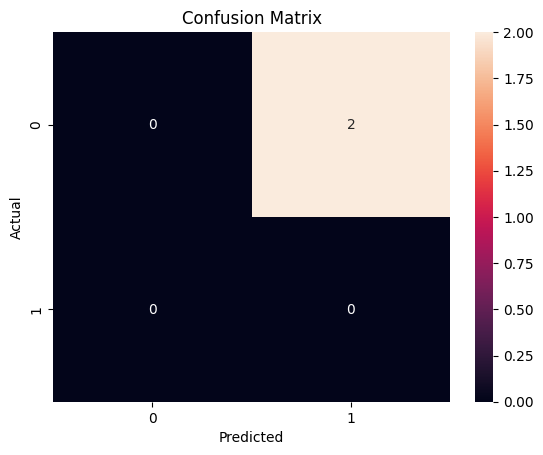

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()